## Enumerate all feasible district plans on synthetic grid graphs with uniform population

### Tests 6×6 trigrid graph across a range of population deviations.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT_DIR))

In [3]:
import os
import pandas as pd

from src.mip import multi_district_mip
from src.utils import make_trigrid_graph
from src.draw import draw_graph

os.makedirs("../../results", exist_ok=True)

#### SET EXPERIMENT PARAMETERS

In [4]:
DEVIATIONS = [0, 1, 2]
CONTIGUITY = ["tree", "dist", "dag", "cut"]
POOL_SIZE = 10000000
TIME_LIMIT = 3600
POOL_SEARCH = 2

## 6×6 Grid

In [5]:
G6 = make_trigrid_graph(6, 6)


print(f"6×6 grid: {G6.number_of_nodes()} nodes, {G6.number_of_edges()} edges")

6×6 grid: 36 nodes, 85 edges


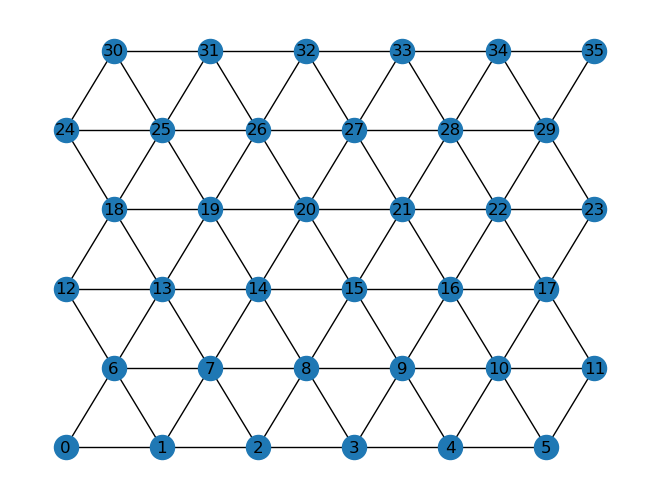

In [6]:
draw_graph(G6)

In [7]:
## ROOT SELECTION
roots = [0, 5, 30, 35]

In [8]:
results = []

for deviation in DEVIATIONS:
    for contiguity in CONTIGUITY:
        print(f"\ndeviation={deviation} | contiguity={contiguity}")

        metrics, _ = multi_district_mip(
            G=G6,
            deviation_persons=deviation,
            contiguity=contiguity,
            roots=roots,
            k=len(roots),
            pool_size=POOL_SIZE,
            pool_search=POOL_SEARCH,
            time_limit=TIME_LIMIT,
        )
        metrics.update(
            {"grid": "6x6", "deviation": deviation, "contiguity": contiguity}
        )

        results.append(
            {key: value for key, value in metrics.items() if key != "districts"}
        )

df = pd.DataFrame(results)
df.to_csv("../../results/small_6x6_tri_enumeration.csv", index=False)


deviation=0 | contiguity=tree
Using L, U, k = 9 9 4
Set parameter Username
Academic license - for non-commercial use only - expires 2027-04-02
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter MIPGap to value 0
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 10000000
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0
PoolSolutions  10000000
PoolSearchMode  2

Optimize a model with 184 rows, 144 columns and 712 nonzeros (Min)
Model fingerprint: 0xbe4ee2f6
Model has 0 linear objective coefficients
Variable types: 0 continuous, 144 integer (144 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [0e+00, 0e+00]
  